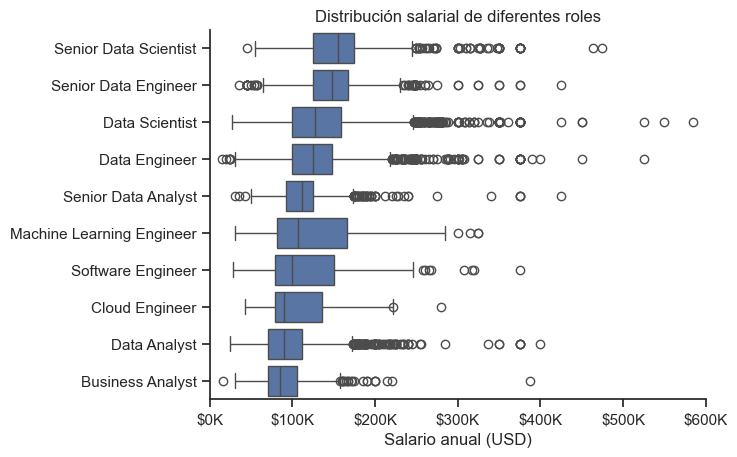

In [2]:
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset


dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df = df.dropna(subset="salary_year_avg")
median_salary = df.groupby("job_title_short")["salary_year_avg"].median().sort_values(ascending=False).head(10).index.tolist()
filtered = df[df["job_title_short"].isin(median_salary)]

sns.boxplot(data=filtered, x='salary_year_avg', y='job_title_short', order = median_salary)
sns.set_theme(style='ticks')
sns.despine()

plt.title('Distribución salarial de diferentes roles')
plt.xlabel('Salario anual (USD)')
plt.ylabel('')
plt.xlim(0, 600000) 
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()











